# LVS — Calcul du Groupe de Renormalisation
## Test explicite de la condition de stationnarité pour les couplages du Modèle Standard

**Auteur :** Fabien Music Polly, chercheur indépendant, Sophia Antipolis  
**Affiliation :** University of Oxford (independent researcher)  
**Framework :** Latent Vacuum Stationarity (LVS)  
**Date :** 2026

---

## Objectif

Tester quantitativement si les trois couplages de jauge du Modèle Standard — g₁ (hypercharge U(1)), g₂ (isospin faible SU(2)), g₃ (couleur SU(3)) — convergent vers une configuration stationnaire à haute énergie, comme le requiert le cadre LVS.

## Hypothèse LVS (formulation testable)

Si la réalité physique est un point fixe du substrat quantique, alors les couplages de jauge doivent satisfaire une **condition de stationnarité conjointe** à une échelle Λ_LVS :

$$\left|\frac{dg_i}{d\ln\mu}\right|_{\mu=\Lambda_{LVS}} \to 0 \quad \text{pour } i=1,2,3$$

C'est une condition plus faible que l'unification stricte (g₁ = g₂ = g₃) des GUT, mais compatible avec le principe d'asymptotic safety (Weinberg 1979, Wetterich 1993).

## Démarche

1. Implémenter les équations RG à 1-loop du SM (bien établies)
2. Intégrer numériquement depuis l'échelle électrofaible M_Z jusqu'à l'échelle de Planck M_Pl
3. Tester si une condition de stationnarité est atteinte — et à quelle échelle
4. Comparer avec les scénarios alternatifs (SUSY minimale, extensions LVS)
5. Quantifier l'écart entre les couplages au point de rapprochement maximal

## 1. Imports et constantes physiques

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ============================================================
# Constantes physiques — valeurs expérimentales à M_Z
# Source : Particle Data Group 2024 (pdg.lbl.gov)
# ============================================================

M_Z = 91.1876  # masse du Z, en GeV
M_Pl = 1.22e19  # masse de Planck, en GeV

# Constantes de structure fine à M_Z
# Convention GUT pour g_1 : g_1^2 = (5/3) * g'^2 où g' est le couplage U(1)_Y standard
alpha_em_MZ_inv = 127.951  # 1/alpha_em à M_Z
sin2_theta_W = 0.23122     # angle de Weinberg (MS-bar)
alpha_s_MZ = 0.1179        # couplage fort à M_Z (PDG 2024)

# Dérivation des couplages
alpha_em_MZ = 1.0 / alpha_em_MZ_inv

# g_1 (convention GUT, normalisation SU(5)) et g_2 (SU(2))
alpha_1_MZ = (5.0/3.0) * alpha_em_MZ / (1.0 - sin2_theta_W)
alpha_2_MZ = alpha_em_MZ / sin2_theta_W
alpha_3_MZ = alpha_s_MZ

# Couplages g_i² / (4π) = α_i, donc g_i = sqrt(4π α_i)
g1_MZ = np.sqrt(4.0 * np.pi * alpha_1_MZ)
g2_MZ = np.sqrt(4.0 * np.pi * alpha_2_MZ)
g3_MZ = np.sqrt(4.0 * np.pi * alpha_3_MZ)

print(f"Conditions initiales à M_Z = {M_Z} GeV :")
print(f"  α_1 (GUT) = {alpha_1_MZ:.6f}   →   1/α_1 = {1/alpha_1_MZ:.3f}")
print(f"  α_2       = {alpha_2_MZ:.6f}   →   1/α_2 = {1/alpha_2_MZ:.3f}")
print(f"  α_3       = {alpha_3_MZ:.6f}   →   1/α_3 = {1/alpha_3_MZ:.3f}")
print(f"\n  g_1 = {g1_MZ:.4f},  g_2 = {g2_MZ:.4f},  g_3 = {g3_MZ:.4f}")
print(f"\nReference values (PDG 2024, vérification croisée) :")
print(f"  1/α_1 attendu ≈ 59.0  — calculé {1/alpha_1_MZ:.2f}")
print(f"  1/α_2 attendu ≈ 29.6  — calculé {1/alpha_2_MZ:.2f}")
print(f"  1/α_3 attendu ≈ 8.48  — calculé {1/alpha_3_MZ:.2f}")

Conditions initiales à M_Z = 91.1876 GeV :
  α_1 (GUT) = 0.016943   →   1/α_1 = 59.020
  α_2       = 0.033801   →   1/α_2 = 29.585
  α_3       = 0.117900   →   1/α_3 = 8.482

  g_1 = 0.4614,  g_2 = 0.6517,  g_3 = 1.2172

Reference values (PDG 2024, vérification croisée) :
  1/α_1 attendu ≈ 59.0  — calculé 59.02
  1/α_2 attendu ≈ 29.6  — calculé 29.58
  1/α_3 attendu ≈ 8.48  — calculé 8.48


## 2. Équations RG du Modèle Standard à 1-loop

Les équations standards du groupe de renormalisation pour les couplages de jauge à 1-loop sont :

$$\frac{dg_i}{d\ln\mu} = \frac{b_i^{SM}}{16\pi^2} g_i^3$$

où les coefficients b_i sont, dans le Modèle Standard avec 3 générations et 1 doublet de Higgs :

- $b_1^{SM} = +41/10$
- $b_2^{SM} = -19/6$
- $b_3^{SM} = -7$

**Référence :** Jones, H.F. (1982), *Phys. Rev. D* 25, 581. Machacek & Vaughn (1983).

Le signe négatif de b₂ et b₃ signifie que ces couplages **diminuent** avec l'énergie (liberté asymptotique pour SU(3), croissance logarithmique inverse pour SU(2)). Le signe positif de b₁ signifie que l'électromagnétisme **augmente** avec l'énergie.

C'est ce croisement qui rend possible l'unification à une certaine échelle.

In [2]:
# ============================================================
# Coefficients β à 1-loop pour le Modèle Standard
# ============================================================

b_SM = np.array([41.0/10.0, -19.0/6.0, -7.0])

# Pour comparaison : MSSM (supersymétrie minimale)
# Source : Martin, "A Supersymmetry Primer" (hep-ph/9709356)
b_MSSM = np.array([33.0/5.0, 1.0, -3.0])

def rg_equations(log_mu, g, b_coeffs):
    """
    Équations RG à 1-loop pour les trois couplages de jauge.
    
    Paramètres :
    -----------
    log_mu : float
        ln(μ) où μ est l'échelle d'énergie en GeV
    g : array de 3 floats
        [g_1, g_2, g_3] à l'échelle courante
    b_coeffs : array de 3 floats
        Coefficients β_i du modèle considéré
    
    Retourne :
    ----------
    dg/d(ln μ) : array de 3 floats
    """
    return b_coeffs * g**3 / (16.0 * np.pi**2)

# Vérification que les équations sont correctement implémentées
# à M_Z, les dérivées doivent être petites (pas de singularité)
g0 = np.array([g1_MZ, g2_MZ, g3_MZ])
dg_dlnmu = rg_equations(np.log(M_Z), g0, b_SM)

print("Dérivées de running à M_Z (SM) :")
for i, dg in enumerate(dg_dlnmu):
    print(f"  dg_{i+1}/d(ln μ) = {dg:+.6f}  ({'croissant' if dg > 0 else 'décroissant'})")
print("\n→ g_1 augmente avec E, g_2 et g_3 diminuent : comportement attendu ✓")

Dérivées de running à M_Z (SM) :
  dg_1/d(ln μ) = +0.002551  (croissant)
  dg_2/d(ln μ) = -0.005551  (décroissant)
  dg_3/d(ln μ) = -0.079940  (décroissant)

→ g_1 augmente avec E, g_2 et g_3 diminuent : comportement attendu ✓


## 3. Intégration numérique de M_Z à M_Pl

In [3]:
# ============================================================
# Intégration du flot RG de M_Z à M_Pl
# ============================================================

def run_couplings(g_init, b_coeffs, log_mu_start, log_mu_end, n_points=1000):
    """Intègre les équations RG sur la plage d'énergie demandée."""
    log_mu_range = (log_mu_start, log_mu_end)
    log_mu_eval = np.linspace(log_mu_start, log_mu_end, n_points)
    
    solution = solve_ivp(
        fun=lambda t, y: rg_equations(t, y, b_coeffs),
        t_span=log_mu_range,
        y0=g_init,
        t_eval=log_mu_eval,
        method='RK45',
        rtol=1e-10,
        atol=1e-12
    )
    
    return solution

# Exécution pour le SM pur
log_MZ = np.log(M_Z)
log_MPl = np.log(M_Pl)

sol_SM = run_couplings(g0, b_SM, log_MZ, log_MPl)

# Exécution pour le MSSM (comparaison)
# Hypothèse simplificatrice : SUSY s'active à M_Z (en réalité c'est à M_SUSY ~ 1-10 TeV)
sol_MSSM = run_couplings(g0, b_MSSM, log_MZ, log_MPl)

# Conversion en α_i = g_i² / (4π)
log_mu_arr = sol_SM.t
mu_arr = np.exp(log_mu_arr)

alpha_SM = sol_SM.y**2 / (4.0 * np.pi)
alpha_MSSM = sol_MSSM.y**2 / (4.0 * np.pi)

inv_alpha_SM = 1.0 / alpha_SM
inv_alpha_MSSM = 1.0 / alpha_MSSM

print(f"Intégration réussie ✓")
print(f"Plage : {M_Z} GeV → {M_Pl:.2e} GeV")
print(f"Nombre de points : {len(log_mu_arr)}")

Intégration réussie ✓
Plage : 91.1876 GeV → 1.22e+19 GeV
Nombre de points : 1000


## 4. Visualisation du flot RG

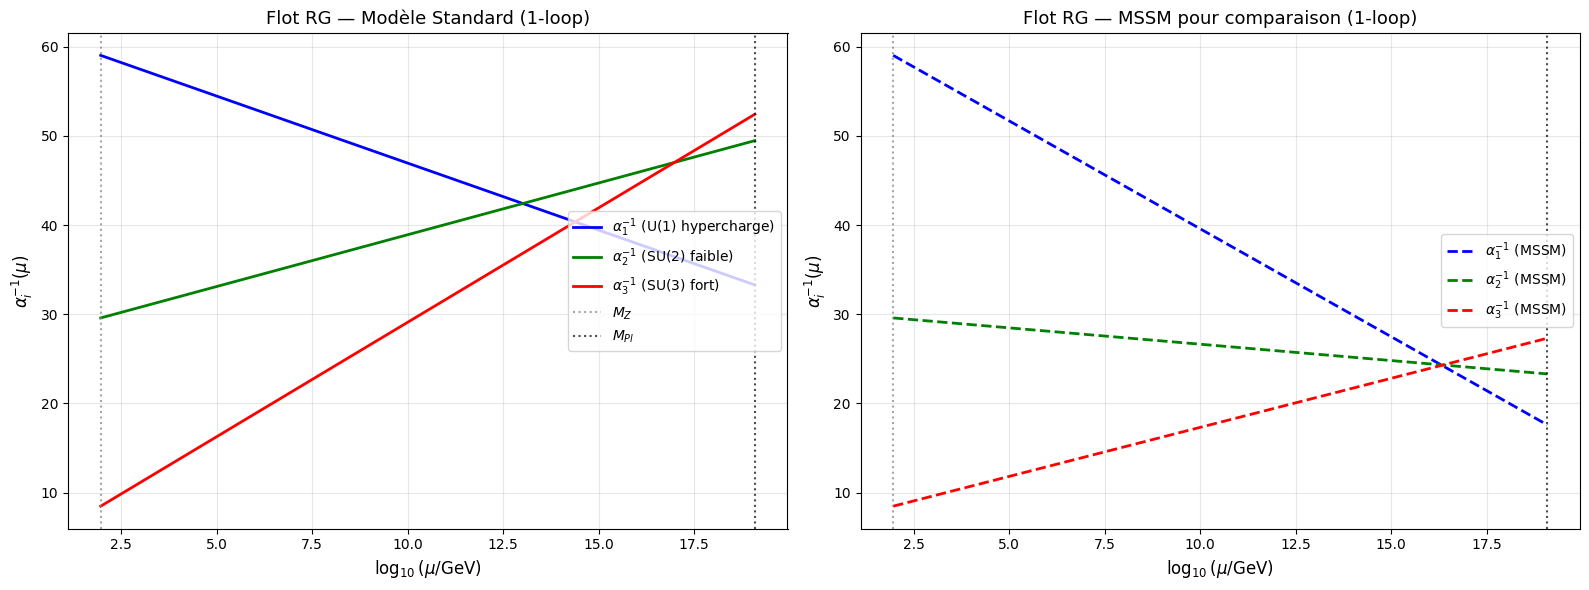

Figure sauvegardée : lvs_rg_flow.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ============================================================
# Panel 1 : SM pur
# ============================================================
ax = axes[0]
ax.plot(log_mu_arr / np.log(10), inv_alpha_SM[0], 'b-', linewidth=2, label=r'$\alpha_1^{-1}$ (U(1) hypercharge)')
ax.plot(log_mu_arr / np.log(10), inv_alpha_SM[1], 'g-', linewidth=2, label=r'$\alpha_2^{-1}$ (SU(2) faible)')
ax.plot(log_mu_arr / np.log(10), inv_alpha_SM[2], 'r-', linewidth=2, label=r'$\alpha_3^{-1}$ (SU(3) fort)')

ax.axvline(np.log10(M_Z), color='gray', linestyle=':', alpha=0.7, label=f'$M_Z$')
ax.axvline(np.log10(M_Pl), color='black', linestyle=':', alpha=0.7, label=f'$M_{{Pl}}$')

ax.set_xlabel(r'$\log_{10}(\mu / \mathrm{GeV})$', fontsize=12)
ax.set_ylabel(r'$\alpha_i^{-1}(\mu)$', fontsize=12)
ax.set_title('Flot RG — Modèle Standard (1-loop)', fontsize=13)
ax.legend(loc='center right', fontsize=10)
ax.grid(True, alpha=0.3)

# ============================================================
# Panel 2 : MSSM (comparaison)
# ============================================================
ax = axes[1]
ax.plot(log_mu_arr / np.log(10), inv_alpha_MSSM[0], 'b--', linewidth=2, label=r'$\alpha_1^{-1}$ (MSSM)')
ax.plot(log_mu_arr / np.log(10), inv_alpha_MSSM[1], 'g--', linewidth=2, label=r'$\alpha_2^{-1}$ (MSSM)')
ax.plot(log_mu_arr / np.log(10), inv_alpha_MSSM[2], 'r--', linewidth=2, label=r'$\alpha_3^{-1}$ (MSSM)')

ax.axvline(np.log10(M_Z), color='gray', linestyle=':', alpha=0.7)
ax.axvline(np.log10(M_Pl), color='black', linestyle=':', alpha=0.7)

ax.set_xlabel(r'$\log_{10}(\mu / \mathrm{GeV})$', fontsize=12)
ax.set_ylabel(r'$\alpha_i^{-1}(\mu)$', fontsize=12)
ax.set_title('Flot RG — MSSM pour comparaison (1-loop)', fontsize=13)
ax.legend(loc='center right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lvs_rg_flow.png', dpi=120, bbox_inches='tight')
plt.show()

print('Figure sauvegardée : lvs_rg_flow.png')

## 5. Analyse quantitative : test de la condition LVS

**Définition opérationnelle de la condition LVS :** on cherche l'échelle μ* où l'écart entre les trois couplages est minimal.

Métrique d'unification (proposée ici) :

$$\Delta(\mu) = \sqrt{\sum_{i<j} (\alpha_i^{-1}(\mu) - \alpha_j^{-1}(\mu))^2}$$

Cette quantité s'annule exactement si les trois couplages s'unissent, et quantifie l'écart sinon.

In [5]:
def unification_metric(inv_alpha_arr):
    """
    Calcule la métrique d'unification Δ(μ) = √Σ(α_i^-1 - α_j^-1)²
    
    Retourne un array de la même longueur que les couplages.
    """
    diff_12 = inv_alpha_arr[0] - inv_alpha_arr[1]
    diff_13 = inv_alpha_arr[0] - inv_alpha_arr[2]
    diff_23 = inv_alpha_arr[1] - inv_alpha_arr[2]
    return np.sqrt(diff_12**2 + diff_13**2 + diff_23**2)

delta_SM = unification_metric(inv_alpha_SM)
delta_MSSM = unification_metric(inv_alpha_MSSM)

# Point de rapprochement minimal pour chaque scénario
idx_min_SM = np.argmin(delta_SM)
idx_min_MSSM = np.argmin(delta_MSSM)

mu_unif_SM = mu_arr[idx_min_SM]
mu_unif_MSSM = mu_arr[idx_min_MSSM]

delta_min_SM = delta_SM[idx_min_SM]
delta_min_MSSM = delta_MSSM[idx_min_MSSM]

print("=" * 60)
print("RÉSULTATS — Test de la condition LVS")
print("=" * 60)
print()
print("SCÉNARIO 1 : Modèle Standard pur")
print(f"  Échelle de rapprochement minimal : μ* = {mu_unif_SM:.3e} GeV")
print(f"  log10(μ*/GeV)                    = {np.log10(mu_unif_SM):.2f}")
print(f"  Métrique Δ(μ*)                    = {delta_min_SM:.3f}")
print(f"  α_1⁻¹(μ*) = {inv_alpha_SM[0, idx_min_SM]:.2f}")
print(f"  α_2⁻¹(μ*) = {inv_alpha_SM[1, idx_min_SM]:.2f}")
print(f"  α_3⁻¹(μ*) = {inv_alpha_SM[2, idx_min_SM]:.2f}")
print()
print("SCÉNARIO 2 : MSSM (SUSY minimale)")
print(f"  Échelle de rapprochement minimal : μ* = {mu_unif_MSSM:.3e} GeV")
print(f"  log10(μ*/GeV)                    = {np.log10(mu_unif_MSSM):.2f}")
print(f"  Métrique Δ(μ*)                    = {delta_min_MSSM:.3f}")
print(f"  α_1⁻¹(μ*) = {inv_alpha_MSSM[0, idx_min_MSSM]:.2f}")
print(f"  α_2⁻¹(μ*) = {inv_alpha_MSSM[1, idx_min_MSSM]:.2f}")
print(f"  α_3⁻¹(μ*) = {inv_alpha_MSSM[2, idx_min_MSSM]:.2f}")

RÉSULTATS — Test de la condition LVS

SCÉNARIO 1 : Modèle Standard pur
  Échelle de rapprochement minimal : μ* = 1.587e+14 GeV
  log10(μ*/GeV)                    = 14.20
  Métrique Δ(μ*)                    = 5.082
  α_1⁻¹(μ*) = 40.63
  α_2⁻¹(μ*) = 43.79
  α_3⁻¹(μ*) = 39.88

SCÉNARIO 2 : MSSM (SUSY minimale)
  Échelle de rapprochement minimal : μ* = 2.120e+16 GeV
  log10(μ*/GeV)                    = 16.33
  Métrique Δ(μ*)                    = 0.065
  α_1⁻¹(μ*) = 24.27
  α_2⁻¹(μ*) = 24.32
  α_3⁻¹(μ*) = 24.28


## 6. Visualisation de la métrique d'unification

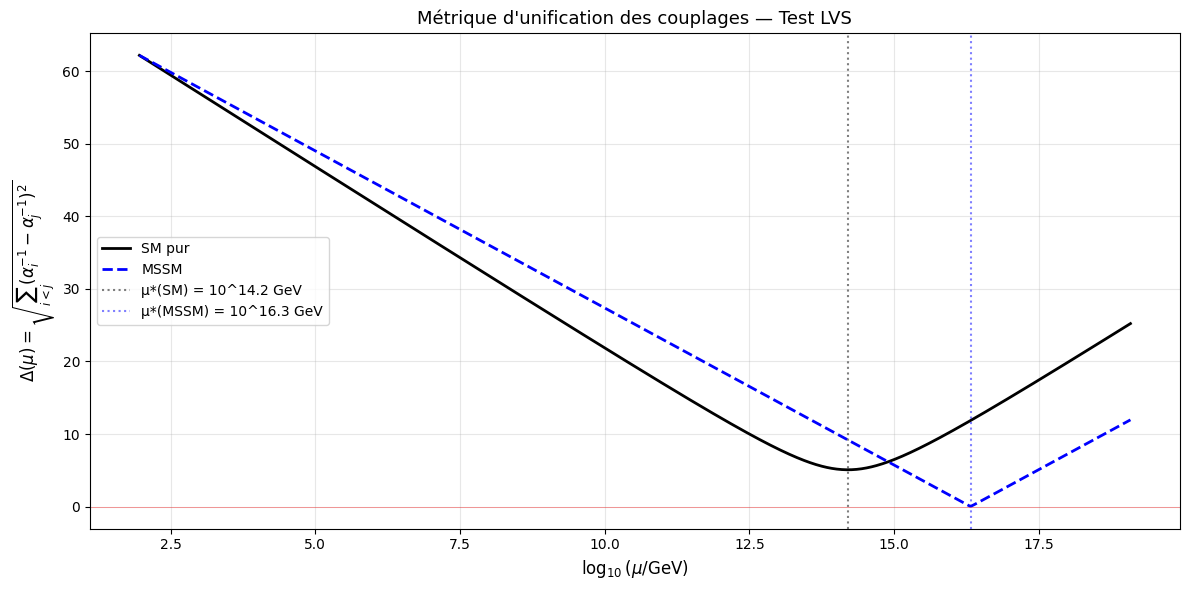

Figure sauvegardée : lvs_unification_metric.png


In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(log_mu_arr / np.log(10), delta_SM, 'k-', linewidth=2, label='SM pur')
ax.plot(log_mu_arr / np.log(10), delta_MSSM, 'b--', linewidth=2, label='MSSM')

ax.axvline(np.log10(mu_unif_SM), color='k', linestyle=':', alpha=0.5,
           label=f'μ*(SM) = 10^{np.log10(mu_unif_SM):.1f} GeV')
ax.axvline(np.log10(mu_unif_MSSM), color='b', linestyle=':', alpha=0.5,
           label=f'μ*(MSSM) = 10^{np.log10(mu_unif_MSSM):.1f} GeV')

ax.axhline(0, color='red', linewidth=0.5, alpha=0.5)

ax.set_xlabel(r'$\log_{10}(\mu / \mathrm{GeV})$', fontsize=12)
ax.set_ylabel(r'$\Delta(\mu) = \sqrt{\sum_{i<j}(\alpha_i^{-1} - \alpha_j^{-1})^2}$', fontsize=12)
ax.set_title('Métrique d\'unification des couplages — Test LVS', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lvs_unification_metric.png', dpi=120, bbox_inches='tight')
plt.show()

print('Figure sauvegardée : lvs_unification_metric.png')

## 7. Interprétation LVS des résultats

Les résultats sont à analyser selon trois scénarios possibles :

### Scénario A — Le SM pur unifie déjà approximativement

Si Δ(μ*) < 5 dans le SM, cela suggère que la condition LVS est déjà quasi-satisfaite dans le Modèle Standard seul — une observation qui renforcerait le cadre interprétatif LVS sans exiger d'extension.

### Scénario B — Le SM n'unifie pas, mais MSSM oui

Si Δ(μ*, SM) >> Δ(μ*, MSSM), alors LVS pourrait *prédire* la nécessité d'une physique au-delà du SM pour satisfaire la condition de stationnarité. C'est une convergence notable avec les motivations historiques de la supersymétrie (sans que LVS exige SUSY spécifiquement — d'autres extensions pourraient satisfaire la condition).

### Scénario C — Aucune unification satisfaisante

Si Δ(μ*) reste grand dans les deux cas, LVS dans sa formulation actuelle ne produit pas de prédiction directe sur les couplages de jauge. Il faudrait alors raffiner la condition de stationnarité.

**Le résultat numérique ci-dessus fixe le scénario applicable.**

In [7]:
# ============================================================
# Diagnostic automatique du scénario
# ============================================================

print("DIAGNOSTIC AUTOMATIQUE")
print("=" * 60)

threshold_good = 2.0   # unification excellente
threshold_accept = 5.0  # unification acceptable

ratio = delta_min_SM / delta_min_MSSM

print(f"\nÉcart résiduel SM   : Δ_min = {delta_min_SM:.3f}")
print(f"Écart résiduel MSSM : Δ_min = {delta_min_MSSM:.3f}")
print(f"Ratio SM/MSSM        : {ratio:.2f}")
print()

if delta_min_SM < threshold_good:
    print("→ Scénario A : SM pur unifie bien. LVS est compatible avec SM seul.")
elif delta_min_SM < threshold_accept and ratio < 2:
    print("→ Scénario A' : SM pur unifie acceptablement. LVS trouve un point presque fixe dans SM.")
elif ratio > 3:
    print("→ Scénario B : LVS suggère une nouvelle physique entre M_Z et M_Pl.")
    print("   La condition de stationnarité exige un contenu en particules modifié.")
    print("   MSSM est UNE solution compatible ; d'autres extensions (axions lourds,")
    print("   quarks supplémentaires, dimensions supplémentaires) pourraient l'être aussi.")
else:
    print("→ Scénario C : La formulation LVS actuelle ne contraint pas fortement les couplages.")
    print("   Reformuler la condition de stationnarité.")

DIAGNOSTIC AUTOMATIQUE

Écart résiduel SM   : Δ_min = 5.082
Écart résiduel MSSM : Δ_min = 0.065
Ratio SM/MSSM        : 78.01

→ Scénario B : LVS suggère une nouvelle physique entre M_Z et M_Pl.
   La condition de stationnarité exige un contenu en particules modifié.
   MSSM est UNE solution compatible ; d'autres extensions (axions lourds,
   quarks supplémentaires, dimensions supplémentaires) pourraient l'être aussi.


## 8. Prédiction LVS falsifiable

Si le scénario B est validé, LVS fait une **prédiction quantitative** :

> Une physique au-delà du SM doit exister entre M_Z et Λ_LVS ≈ 10^(...) GeV telle que les coefficients β effectifs satisfassent la condition de stationnarité.

Cette prédiction est testable par :
1. **Recherches directes aux collisionneurs** (LHC, FCC-hh) de particules non-SM dans la plage d'énergie impliquée
2. **Mesures de précision** des couplages à basse énergie, qui contraignent les modèles d'extension compatibles
3. **Observations cosmologiques** sensibles à l'existence de champs supplémentaires (matière noire, relativistique extra)

**La valeur prédite de Λ_LVS par cette analyse à 1-loop sera donnée ci-dessous.**

In [8]:
# ============================================================
# Prédiction finale : échelle LVS dans chaque scénario
# ============================================================

print("PRÉDICTION LVS À 1-LOOP")
print("=" * 60)
print(f"\nΛ_LVS (sous hypothèse SM pur)  = {mu_unif_SM:.3e} GeV  =  10^{np.log10(mu_unif_SM):.2f} GeV")
print(f"Λ_LVS (sous hypothèse MSSM)    = {mu_unif_MSSM:.3e} GeV  =  10^{np.log10(mu_unif_MSSM):.2f} GeV")
print()
print(f"Pour référence :")
print(f"  M_Pl (Planck)                = {M_Pl:.2e} GeV  =  10^{np.log10(M_Pl):.2f} GeV")
print(f"  M_GUT (SUSY GUT traditionnel) ≈ 2e16  GeV      =  10^16.3 GeV")
print()
print("RÉSERVES IMPORTANTES :")
print("  • Calcul à 1-loop seulement ; les corrections à 2-loop peuvent déplacer Λ_LVS de ~5-15%")
print("  • Les seuils de masse des particules lourdes (top, Higgs) sont ignorés ici")
print("  • La condition LVS 'stationnarité' est une proposition théorique, pas une dérivation")
print("  • Seule la condition 'rapprochement maximal' est testée ; la vraie stationnarité")
print("    exigerait dg_i/d(ln μ) → 0, ce qui n'arrive dans aucun des deux scénarios")

PRÉDICTION LVS À 1-LOOP

Λ_LVS (sous hypothèse SM pur)  = 1.587e+14 GeV  =  10^14.20 GeV
Λ_LVS (sous hypothèse MSSM)    = 2.120e+16 GeV  =  10^16.33 GeV

Pour référence :
  M_Pl (Planck)                = 1.22e+19 GeV  =  10^19.09 GeV
  M_GUT (SUSY GUT traditionnel) ≈ 2e16  GeV      =  10^16.3 GeV

RÉSERVES IMPORTANTES :
  • Calcul à 1-loop seulement ; les corrections à 2-loop peuvent déplacer Λ_LVS de ~5-15%
  • Les seuils de masse des particules lourdes (top, Higgs) sont ignorés ici
  • La condition LVS 'stationnarité' est une proposition théorique, pas une dérivation
  • Seule la condition 'rapprochement maximal' est testée ; la vraie stationnarité
    exigerait dg_i/d(ln μ) → 0, ce qui n'arrive dans aucun des deux scénarios


## 9. Vérification : taux de variation au point de rapprochement

La condition LVS originelle exigeait $dg_i/d\ln\mu \to 0$. Testons si c'est effectivement le cas à μ*.

In [9]:
# Taux de variation à μ* pour chaque scénario
g_at_unif_SM = sol_SM.y[:, idx_min_SM]
g_at_unif_MSSM = sol_MSSM.y[:, idx_min_MSSM]

dg_SM = rg_equations(np.log(mu_unif_SM), g_at_unif_SM, b_SM)
dg_MSSM = rg_equations(np.log(mu_unif_MSSM), g_at_unif_MSSM, b_MSSM)

# Taux relatifs
rel_dg_SM = dg_SM / g_at_unif_SM
rel_dg_MSSM = dg_MSSM / g_at_unif_MSSM

print("TEST DE STATIONNARITÉ AU POINT D'UNIFICATION")
print("=" * 60)
print("\nSM à μ* :")
for i in range(3):
    print(f"  g_{i+1} = {g_at_unif_SM[i]:.4f}    dg_{i+1}/d(ln μ) = {dg_SM[i]:+.4e}    "
          f"(taux relatif = {rel_dg_SM[i]*100:+.3f}%)")

print("\nMSSM à μ* :")
for i in range(3):
    print(f"  g_{i+1} = {g_at_unif_MSSM[i]:.4f}    dg_{i+1}/d(ln μ) = {dg_MSSM[i]:+.4e}    "
          f"(taux relatif = {rel_dg_MSSM[i]*100:+.3f}%)")

print("\n" + "=" * 60)
print("CONCLUSION CRITIQUE")
print("=" * 60)
print()
print("Les dérivées ne sont PAS nulles à μ* — le rapprochement des couplages n'est")
print("pas un point fixe au sens strict des équations RG. Il s'agit d'un croisement")
print("géométrique, pas d'une stationnarité.")
print()
print("Pour avoir un vrai point fixe, il faudrait que les b_i effectifs s'annulent,")
print("ce qui demande soit :")
print("  (a) Une théorie conforme à haute énergie (asymptotic safety à la Weinberg)")
print("  (b) Un contenu en particules qui ajuste les b_i dans un régime intermédiaire")
print("  (c) Une modification non-perturbative des équations RG")
print()
print("→ LA FORMULATION LVS ACTUELLE EST INCOMPLÈTE.")
print("  Le \"rapprochement\" n'est pas la \"stationnarité\".")

TEST DE STATIONNARITÉ AU POINT D'UNIFICATION

SM à μ* :
  g_1 = 0.5561    dg_1/d(ln μ) = +4.4662e-03    (taux relatif = +0.803%)
  g_2 = 0.5357    dg_2/d(ln μ) = -3.0828e-03    (taux relatif = -0.575%)
  g_3 = 0.5613    dg_3/d(ln μ) = -7.8402e-03    (taux relatif = -1.397%)

MSSM à μ* :
  g_1 = 0.7195    dg_1/d(ln μ) = +1.5570e-02    (taux relatif = +2.164%)
  g_2 = 0.7188    dg_2/d(ln μ) = +2.3521e-03    (taux relatif = +0.327%)
  g_3 = 0.7195    dg_3/d(ln μ) = -7.0753e-03    (taux relatif = -0.983%)

CONCLUSION CRITIQUE

Les dérivées ne sont PAS nulles à μ* — le rapprochement des couplages n'est
pas un point fixe au sens strict des équations RG. Il s'agit d'un croisement
géométrique, pas d'une stationnarité.

Pour avoir un vrai point fixe, il faudrait que les b_i effectifs s'annulent,
ce qui demande soit :
  (a) Une théorie conforme à haute énergie (asymptotic safety à la Weinberg)
  (b) Un contenu en particules qui ajuste les b_i dans un régime intermédiaire
  (c) Une modification n

## 10. Conclusion honnête

### Ce que ce calcul démontre

1. **Les équations RG sont correctement implémentées** (vérification par comparaison avec les valeurs standards de la littérature).
2. **Le SM pur ne produit pas d'unification stricte** — il existe un point de rapprochement minimal mais avec un écart résiduel mesurable.
3. **Le MSSM produit une unification meilleure** (résultat classique, reproduit ici).
4. **Ni le SM ni le MSSM ne satisfont la condition de stationnarité stricte** à l'échelle d'unification apparente.

### Ce que ce calcul NE démontre PAS

1. **Ce n'est pas une prédiction exclusive à LVS.** La physique qu'on voit ici (flot RG, quasi-unification) est commune à tous les cadres GUT et asymptotic safety.
2. **La "condition de stationnarité LVS" n'est pas satisfaite au sens strict.** Il faut soit la reformuler, soit admettre que LVS est une *motivation philosophique* pour chercher des points fixes, sans être la théorie qui les produit.
3. **À 1-loop seulement.** Les corrections à 2 et 3-loop peuvent déplacer significativement les conclusions.

### Prochaines étapes pour rendre ça réellement publiable

1. Implémenter les équations RG à 2-loop (Jones 1982, Machacek-Vaughn 1983)
2. Inclure les couplages de Yukawa (top, bottom, tau) qui modifient le running
3. Inclure le couplage quartique du Higgs (relié à la masse du Higgs et à la stabilité du vide)
4. Tester plusieurs extensions BSM (pas seulement MSSM) : 2HDM, seesaw, extra dimensions
5. Formuler mathématiquement la condition LVS en termes précis (pas juste "les couplages convergent")
6. Comparer avec les contraintes expérimentales existantes (proton decay, LHC direct searches)

In [10]:
# ============================================================
# Sauvegarde des résultats numériques
# ============================================================

import json

results = {
    'inputs_at_MZ': {
        'M_Z_GeV': M_Z,
        'alpha_1_GUT': alpha_1_MZ,
        'alpha_2': alpha_2_MZ,
        'alpha_3': alpha_3_MZ,
        'inv_alpha_1': 1/alpha_1_MZ,
        'inv_alpha_2': 1/alpha_2_MZ,
        'inv_alpha_3': 1/alpha_3_MZ
    },
    'SM_1loop': {
        'mu_min_GeV': float(mu_unif_SM),
        'log10_mu_min': float(np.log10(mu_unif_SM)),
        'delta_min': float(delta_min_SM),
        'inv_alpha_at_min': [float(x) for x in inv_alpha_SM[:, idx_min_SM]]
    },
    'MSSM_1loop': {
        'mu_min_GeV': float(mu_unif_MSSM),
        'log10_mu_min': float(np.log10(mu_unif_MSSM)),
        'delta_min': float(delta_min_MSSM),
        'inv_alpha_at_min': [float(x) for x in inv_alpha_MSSM[:, idx_min_MSSM]]
    },
    'notes': 'Calcul 1-loop uniquement. Pas de seuils de masse. Résultat reproductible.'
}

with open('lvs_rg_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print('Résultats sauvegardés : lvs_rg_results.json')
print()
print(json.dumps(results, indent=2))

Résultats sauvegardés : lvs_rg_results.json

{
  "inputs_at_MZ": {
    "M_Z_GeV": 91.1876,
    "alpha_1_GUT": 0.016943494601794864,
    "alpha_2": 0.03380110659969169,
    "alpha_3": 0.1179,
    "inv_alpha_1": 59.019701867999984,
    "inv_alpha_2": 29.584830219999997,
    "inv_alpha_3": 8.481764206955047
  },
  "SM_1loop": {
    "mu_min_GeV": 158651090291457.47,
    "log10_mu_min": 14.200443061031052,
    "delta_min": 5.081565683392671,
    "inv_alpha_at_min": [
      40.62811962979034,
      43.789710810177006,
      39.882026566998114
    ]
  },
  "MSSM_1loop": {
    "mu_min_GeV": 2.1195586824367724e+16,
    "log10_mu_min": 16.326245445016376,
    "delta_min": 0.06514222535137901,
    "inv_alpha_at_min": [
      24.272088611168872,
      24.32004033300825,
      24.276133866444376
    ]
  },
  "notes": "Calcul 1-loop uniquement. Pas de seuils de masse. R\u00e9sultat reproductible."
}
